# Musterlösung 10

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Aufgabe 1

Bei Messungen möchte man häufig die Abhängigkeit einer Messgrösse $y$ von einer unabhängigen Variable $x$ bestimmen. Zum Beispiel, wenn man die Kennlinie einer Diode bestimmt, dann ist die angelegte Spannung $U$ die unabhängige Variable, und man misst den Strom $I$ in Abhängigkeit davon. Wird ein polynomieller Zusammenhang von der Form:

$$y(x) = f(x, \vec{a}) = a_0 + a_1 x + a_2 x^2 + \dots = \sum_{n=0}^{m} a_n x^n \qquad \mathrm{mit}\quad \vec{a} = (a_0, \dots, a_m)$$

erwartet, dann kann man die unbekannten Parameter $a_n$ aufgrund von gemessenen Daten mittels linearem Fitten 
bestimmen.

Von nun an nennen wir das Polynom $f(x, \vec{a})$ das Modell, welches uns für jedes $x$ den erwarteten Messwert gibt. Die tatsächlich gemessenen Werte nennen wir $y_i$, mit der jeweiligen Unsicherheit (Standardabweichung) $\sigma_i$.

## a)

Laden Sie den Datensatz 'lin_data.txt', der eine positionsabhängige Kraft beschreibt, und plotten Sie die Daten mit Fehlerbalken. Verwenden Sie hierzu die Funktion `ax.errorbar` von matplotlib. Schätzen Sie aufgrund des Plots von Hand die Steigung und den Achsenabschnitt der Geraden ab, die den Zusammenhang zwischen Kraft und Ort in diesem Datensatz beschreibt.

### Lösung

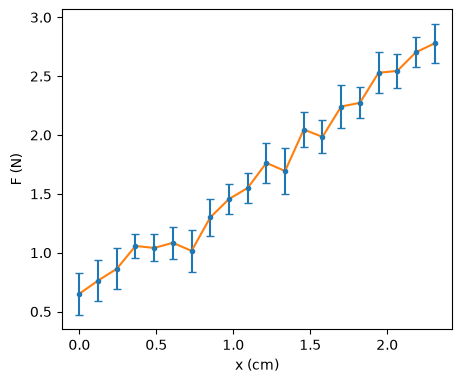

In [23]:
# Daten Laden
data = np.loadtxt('Ex10/lin_data.txt')
x_val = data[:, 0]
y_val = data[:, 1]
sigma_y = data[:, 2]

# Plot erstellen
cm = 1 / 2.54
fig = plt.figure(figsize=(12 * cm, 10 * cm))
ax = fig.add_subplot(1, 1, 1)
ax.errorbar(x_val, y_val, sigma_y , capsize=3, linestyle='None', marker='.')
ax.plot(x_val, y_val, label='Daten')

ax.set_xlabel('x (cm)')
ax.set_ylabel('F (N)')

fig.tight_layout()

Man kann sehen, dass die Daten etwa auf einer Gerade liegen, die die y-Achse bei $y \approx 0.5\,$N schneidet. Die ungefähre Steigung beträgt $1\,$N/cm. Damit wäre die abgschätzte lineare Abhängigkeit gegeben durch

$$F(x) = 0.5\,\mathrm{N} + 1\,\mathrm{N}/\mathrm{cm} \cdot x.$$

## b)

In der Vorlesung haben Sie gesehen, dass das lineare Fitten dem Minimieren der Summe aller Residuenquadrate entspricht. Das heisst, man sucht die Werte für $a_n$, sodass die Summe

$$S = \sum_{n=1}^{N} \frac{(y_i - f(x_i, \vec{a}))^2}{\sigma_i^2}$$

den minimalen Wert annimmt. (Die Differenzen der Messwerte $y_i$ und der erwarteten Werte $f(x_i, \vec{a})$ heissen Residuen.)

Wie Sie im Plot aus a) gesehen haben, ist der Zusammenhang bei diesen Daten linear, d.h. wir haben $m = 1$ und das Modell ist

$$ f(x, a_0, a_1) = a_0 + a_1 x.$$

Berechnen Sie die Summe $S$ der Residuenquadrate für verschiedene Kombinationen von Werten für $a_0$ und $a_1$ in einem Bereich um die Werte, die Sie in a) von Hand abgeschätzt haben. Nehmen Sie z.B. für $a_0$ fünfzig Werte im Intervall $[-0.5, 1.5]$ und für $a_1$ sechzig Werte im Intervall $[0, 2]$, und berechnen Sie $S$ für alle $50 \times 60$ Kombinationen. 

Plotten Sie $\log(S)$ abhängig von $a_0$ und $a_1$ mithilfe von `ax.pcolormesh` als 2D-Plot. Orientieren Sie sich an dem Beispiel unten für das Erstellen des Plots. Sie sollten ein Minimum sehen, das den optimalen Werten für $a_0$ und $a_1$ entspricht. Stimmt die Position des Minimums mit den Werten, die Sie in a) erhalten haben, überein?

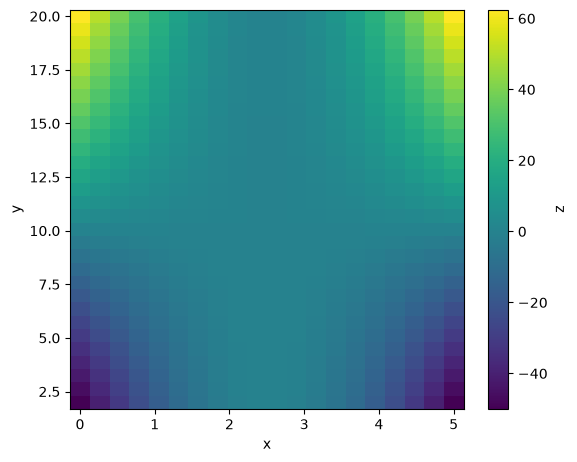

In [24]:
# Erzeuge einige Daten zum Plotten
x_example = np.linspace(0, 5, 20)
y_example = np.linspace(2, 20, 30)
z_example = np.zeros(shape=(len(x_example), len(y_example)))

for i, x in enumerate(x_example):
    for j, y in enumerate(y_example):
        z_example[i][j] = (x - 2.5)**2 * (y - 10)

    
# 2D-Plot generieren
cm = 1 / 2.54

fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

# Beachten Sie, dass das Z-Array transponiert werden muss (.T), weil die
# pcolormesh erwartet, dass die erste Achse (äusseres Array) den vertikalen
# Pixeln (y-Achse) enspricht und die zweite Achse (inneres Array) den horizontalen.
im = ax.pcolormesh(x_example, y_example, z_example.T, shading='nearest')

# Colorbar für die Farbskala, mit Achsenbeschriftung
fig.colorbar(im, label='z')

ax.set_xlabel('x')
ax.set_ylabel('y')

fig.tight_layout()

### Lösung

In [25]:
# Wertebereiche für a0 und a1 definieren
a0_range = np.linspace(-0.5, 1.5, 50)
a1_range = np.linspace(0, 2, 60)

# Array für die berechneten S initialisieren
S = np.zeros(shape=(50, 60))

# S für alle Kombinationen berechnen
for i, a0 in enumerate(a0_range):
    for j, a1 in enumerate(a1_range):
        S[i, j] = np.sum((y_val - (a0 + a1 * x_val))**2 / sigma_y**2)

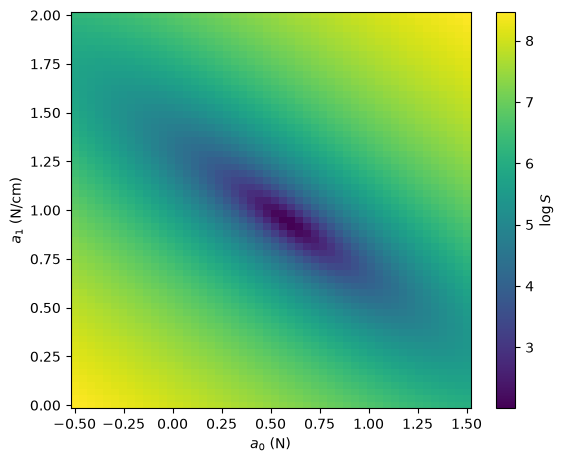

In [26]:
cm = 1 / 2.54
fig = plt.figure(figsize=(15 * cm, 12 * cm))
ax = fig.add_subplot(1, 1, 1)

im = ax.pcolormesh(a0_range, a1_range, np.log(S).T, shading='nearest')
fig.colorbar(im, label=r'$\log S$')

ax.set_xlabel('$a_0$ (N)')
ax.set_ylabel('$a_1$ (N/cm)')

fig.tight_layout()

Man sieht ein deutliches Minimum in der nähe von $a_0 = 0.5\,\mathrm{N}$, $a_1 = 1\,\mathrm{N}/\mathrm{cm}$, was mit den Werten aus a) übereinstimmt.

## c)

Bestimmen Sie die optimalen Parameter $a_0$ und $a_1$ und deren Unsicherheiten mit der analytischen Methode aus der Vorlesung. Berechnen Sie dazu die Normalmatrix

$$
N = \begin{pmatrix}\sum_i w_i & \sum_i w_i x_i \\ \sum_i w_i x_i & \sum_i w_i x_i^2 \end{pmatrix}
$$

und den Vektor

$$
\vec{Y} = \begin{pmatrix} \sum_i w_i y_i \\ \sum_i w_i x_i y_i \end{pmatrix},
$$

wobei die Gewichte $w_i = 1 / \sigma_i^2$ durch die Unsicherheiten der Datenpunkte gegeben sind. Plotten Sie anschliessend die Daten zusammen mit dem Fit, um Ihr Resultat zu überprüfen.

Hinweise:

- Sie können 2-dimensionale Arrays verwenden, um Matrizen zu speichern.
- Um eine Matrix zu invertieren, verwenden Sie die Funktion `np.linalg.inv`.
- Für das Matrixprodukt können Sie die Notation `A @ B` oder `np.dot(A, B)` verwenden.

### Lösung

In [27]:
N = np.zeros(shape=(2, 2))
Y = np.zeros(shape=(2,))  # '(2,)' ist ein Tupel mit nur einem Eintrag. '(2)' ohne Komma gibt ein Integer.

# N und Y berechnen. Da wir hier ein Polynom ersten Grades fitten (m = 1), können wir einfach
# jedes Element einzeln hinschreiben.
# Allgemeinere Lösung siehe unten.
N[0, 0] = np.sum(1 / sigma_y**2)
N[0, 1] = np.sum(x_val / sigma_y**2)
N[1, 0] = np.sum(x_val / sigma_y**2)
N[1, 1] = np.sum(x_val**2 / sigma_y**2)

Y[0] = np.sum(y_val / sigma_y**2)
Y[1] = np.sum(y_val * x_val / sigma_y**2)

# Lösungsvektor
a0, a1 = np.linalg.inv(N) @ Y

# Kovarianzmatrix
# Die Unsicherheiten (Standardabweichung) der gefitteten Parameter bekommt man
# aus der Wurzel der Diagonaleinträge.
C = np.linalg.inv(N)
sig_a0 = np.sqrt(C[0, 0])
sig_a1 = np.sqrt(C[1, 1])

# Resultate ausgeben (Unicode string für das "Plusminus"-Zeichen)
print(u'a_0 = ({:.3f} \u00b1 {:.3f}) N\na_1 = ({:.3f} \u00b1 {:.3f}) N/cm'.format(a0, sig_a0, a1, sig_a1))

a_0 = (0.588 ± 0.063) N
a_1 = (0.939 ± 0.047) N/cm


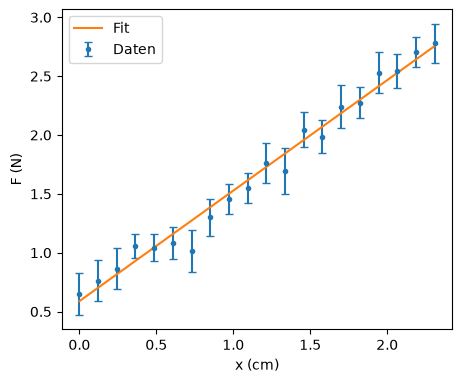

In [28]:
# Daten und Fit plotten.
cm = 1 / 2.54
fig = plt.figure(figsize=(12 * cm, 10 * cm))
ax = fig.add_subplot(1, 1, 1)

ax.errorbar(x_val, y_val, sigma_y, capsize=3, linestyle='None', marker='.', label='Daten')
ax.plot(x_val, a0 + a1 * x_val, label='Fit')
ax.legend()

ax.set_xlabel('x (cm)')
ax.set_ylabel('F (N)')

fig.tight_layout()

## d)

Schreiben Sie eine Funktion, die einen Datensatz mit einem Polynom beliebiger Ordnung fittet, d.h. die optimalen Parameter $a_i$ findet. Die Funktion soll als Argumente nehmen:

- Die Werte $x_i$ der unabhängigen Variable.
- Die gemessenen Werte $y_i$.
- Die dazugehörigen Unsicherheiten $\sigma_i$.
- Den Grad $m$ des Polynoms, das gefittet werden soll.

Die Rückgabewerte der Funktion sollen der Lösungsvektor $\vec{a}$, also die Koeffizienten des gefitteten Polynoms, und deren Kovarianzmatrix $C$ sein.

Wenden Sie die Funktion auf den Datensatz 'poly_data.txt' an und berechnen Sie die Fits mit $m = 4$, $m=5$ und $m=6$. Plotten Sie den Fit $f(x,\vec{a}_{\mathrm{opt}})$ und die Residuen für die drei Fälle. Was können Sie aus Ihren Plots schliessen? Können Sie zum Beispiel ahnand der Residuen erkennen, ob Ihr Modell die Daten gut beschreibt? Was passiert, wenn sie unterfitten (d.h. wenn das Modell zu wenige Freiheitsgrade hat) und wenn Sie überfitten (zu viele Freiheitsgrade)?

### Lösung

In [ ]:
def linear_fit(x, y, sigma, m):
    '''Perform a linear fit with a polynomial of order m. Returns an array of length m containing
    the optimized coefficients of the fit.'''
    # Gewichte
    w = 1 / sigma**2
    
    # N und Y berechnen. Ein Polynom von Grad m hat m+1 Koeffizienten.
    N = np.zeros(shape=(m+1, m+1))
    Y = np.zeros(shape=(m+1, ))
    
    # Durch Betrachten der Normalmatrix kann man erkennen, dass der Exponent
    # von x in jedem Eintrag der Summe Indizes diese Eintrags entspricht.
    # Ähnlich ist es beim Vektor Y.
    for i in range(m + 1):
        Y[i] = np.sum(w * y * x**i)
        for j in range(m + 1):
            
            N[i, j] = np.sum(w * x**(i+j))
            
    # Kovarianzmatrix
    C = np.linalg.inv(N)
    # Lösungsvektor berechnen und ausgeben
    a_vec = C @ Y
    return a_vec, C

In [ ]:
# Neuen Datensatz laden
data = np.loadtxt('Ex10/poly_data.txt')
u_val = data[:, 0]
i_val = data[:, 1]
sigma_i = data[:, 2]

In [ ]:
# Berechne den Fit für verschiedene m

m = 3
# Lösungsvektor mit der Funktion von oben berechnen.
a_vec_m3, C_m3 = linear_fit(u_val, i_val, sigma_i, m)

# Die erwarteten y-Werte aus dem Fit sind
#    f(x_i, a_opt) = a0 + a1 * x + a2 * x**2 + ... + a_m * x**m.
# Für jeden Datenpunkt x_i müssen wir also die Summe über n von a_n x_i**n berechnen
i_fit_m3 = np.zeros(len(u_val))
for index, x_i in enumerate(u_val):
    sum_i = 0
    for n, a_n in enumerate(a_vec_m3):
        sum_i += a_n * x_i**n
        
    i_fit_m3[index] = sum_i


# Das gleiche für m = 4 und m = 5.
m = 4
a_vec_m4, C_m4 = linear_fit(u_val, i_val, sigma_i, m)

i_fit_m4 = np.zeros(len(u_val))
for index, x_i in enumerate(u_val):
    sum_i = 0
    for n, a_n in enumerate(a_vec_m4):
        sum_i += a_n * x_i**n
        
    i_fit_m4[index] = sum_i
    
m = 5
a_vec_m5, C_m5 = linear_fit(u_val, i_val, sigma_i, m)

i_fit_m5 = np.zeros(len(u_val))
for index, x_i in enumerate(u_val):
    sum_i = 0
    for n, a_n in enumerate(a_vec_m5):
        sum_i += a_n * x_i**n
        
    i_fit_m5[index] = sum_i

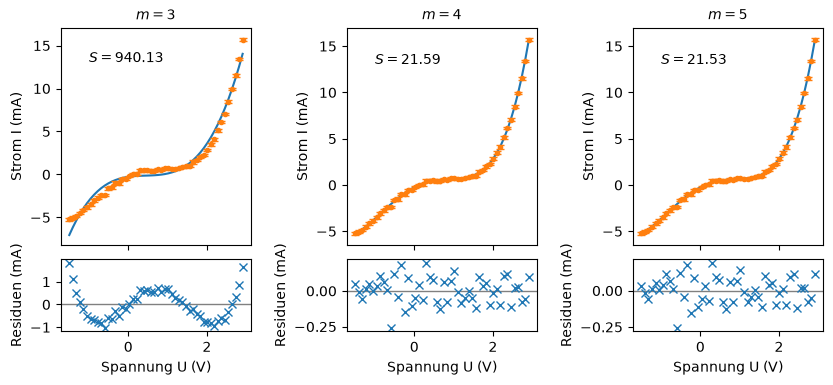

In [ ]:
# Um mehr Kontrolle über die Anordnung von Plots auf einem Gitter zu haben, verwenden wir
# matplotlib.gridspec
import matplotlib.gridspec as gs

# Plotten
cm = 1 / 2.54
fig = plt.figure(figsize=(25 * cm, 10 * cm))

# Definere das Gitter-Layout mit unterschiedlicher Höhe für die zwei Zeilen.
gs0 = gs.GridSpec(nrows=2, ncols=3, height_ratios=[3, 1], hspace=.1, figure=fig)


###### m = 3
# Plots hinzufügen geht dann so:
ax1 = fig.add_subplot(gs0[0, 0])

# Der Rest wie gewohnt
ax1.plot(u_val, i_fit_m3)
ax1.errorbar(u_val, i_val, sigma_i, capsize=3, linestyle='None', marker='.')

ax1.set_ylabel('Strom I (mA)')
ax1.set_xticklabels([])  # Entferne Labels, weil die Achse gleich wie im Plot unten ist
ax1.set_title('$m = 3$', size=10)

ax1.text(-1, 13, '$S = ${:.2f}'.format(np.sum((i_val - i_fit_m3)**2 / sigma_i**2)))

# Residuen
ax2 = fig.add_subplot(gs0[1, 0])
ax2.axhline(0, color='0.5', linewidth=1)
ax2.plot(u_val, i_val - i_fit_m3, 'x')

ax2.set_xlabel('Spannung U (V)')
ax2.set_ylabel('Residuen (mA)')


###### m = 4
ax3 = fig.add_subplot(gs0[0, 1])

ax3.plot(u_val, i_fit_m4)
ax3.errorbar(u_val, i_val, sigma_i, capsize=3, linestyle='None', marker='.')

ax3.set_ylabel('Strom I (mA)')
ax3.set_xticklabels([])
ax3.set_title('$m = 4$', size=10)

ax3.text(-1, 13, '$S = ${:.2f}'.format(np.sum((i_val - i_fit_m4)**2 / sigma_i**2)))
         
# Residuen
ax4 = fig.add_subplot(gs0[1, 1])
ax4.axhline(0, color='0.5', linewidth=1)
ax4.plot(u_val, i_val - i_fit_m4, 'x')

ax4.set_xlabel('Spannung U (V)')
ax4.set_ylabel('Residuen (mA)')


###### m = 5
ax5 = fig.add_subplot(gs0[0, 2])

ax5.plot(u_val, i_fit_m5)
ax5.errorbar(u_val, i_val, sigma_i, capsize=3, linestyle='None', marker='.')

ax5.set_ylabel('Strom I (mA)')
ax5.set_xticklabels([])
ax5.set_title('$m = 5$', size=10)

ax5.text(-1, 13, '$S = ${:.2f}'.format(np.sum((i_val - i_fit_m5)**2 / sigma_i**2)))
         
# Residuen
ax6 = fig.add_subplot(gs0[1, 2])
ax6.axhline(0, color='0.5', linewidth=1)
ax6.plot(u_val, i_val - i_fit_m5, 'x')

ax6.set_xlabel('Spannung U (V)')
ax6.set_ylabel('Residuen (mA)')


##
fig.subplots_adjust(wspace=.5)  # Layout anpassen, damit die Achsenbeschriftungen nicht überlappen

Für $m=3$ weicht der Fit deutlich von den Datenpunkten ab und auch die Residuen zeigen eine klare Struktur. Wenn die Residuen nicht zufällig verteilt sind, deutet das darauf hin, dass das Modell unzureichend komplex für die Daten ist.

Für $m=4$ ist keine Struktur mehr in den Residuen zu erkennen. Ein Polynom fünften Grades beschreibt hier also den Zusammenhang zwischen Strom und Spannung gut.

Durch Erhöhen von $m$ auf 5 kann man die gewichtete Summe $S$ der Residuenquadrate noch ein wenig reduzieren, was aber nicht bedeutet, dass ein Polynom sechsten Grades hier das bessere Modell ist: Man kann nämlich einen Datensatz mit $N$ Punkten immer perfekt fitten, wenn man ein Polynom $N$-ten Grades verwendet. Allerdings haben aber dann die Fitparameter keine physikalische Bedeutung mehr.

Beim Fitten von Daten sollte man also ein physikalisch motivertes Modell nehmen, und nicht einfach die Anzahl Freiheitsgrade (Fitparameter) erhöhen, bis der Fit passt.